# 03 - Baseline Models
Notebook skeleton created.

## Baselines classiques (BoW, TF-IDF, bigrams)

Ce notebook entraîne les baselines demandées et exporte les résultats dans `results/tables` et `results/confusion_matrices`.

In [1]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.baseline_models import run_baseline_suite
from src.metrics import save_confusion_matrix_plot
from src.utils import RESULTS_ROOT, PROCESSED_ROOT, ensure_dir

sns.set_theme(style='whitegrid', context='talk')

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

version_dir = PROCESSED_ROOT / 'protocol_a_main_ml1231_dualview_v1'
index_path = version_dir / 'adfa_processed_index.parquet'
features_path = version_dir / 'baseline_features.pkl'

if not index_path.exists():
    raise FileNotFoundError(f'Missing processed index: {index_path}')
if not features_path.exists():
    raise FileNotFoundError(f'Missing baseline features: {features_path}')

index_df = pd.read_parquet(index_path)
with features_path.open('rb') as f:
    features = pickle.load(f)

print('Loaded index rows:', len(index_df))
print('Available feature sets:', [k for k in features.keys() if k in ['bow', 'tfidf', 'bigram']])

Loaded index rows: 5951
Available feature sets: ['bow', 'tfidf', 'bigram']


In [2]:
train_df = index_df[index_df['split'] == 'train'].reset_index(drop=True)
val_df = index_df[index_df['split'] == 'val'].reset_index(drop=True)
test_df = index_df[index_df['split'] == 'test'].reset_index(drop=True)

y_train = train_df['label_binary'].astype(int).to_numpy()
y_val = val_df['label_binary'].astype(int).to_numpy()
y_test = test_df['label_binary'].astype(int).to_numpy()

results_df, trained_models, pred_pack = run_baseline_suite(
    features=features,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    random_state=int(cfg.get('project', {}).get('seed', 42)),
)

display(results_df)

,model,algorithm,feature_set,split,accuracy,precision,recall,f1,fpr,fnr,tp,tn,fp,fn,roc_auc,pr_auc
0,rf_tfidf,rf,tfidf,test,0.809487,0.396373,0.927273,0.555354,0.207850,0.072727,153.0,888.0,233.0,12.0,0.928714,0.641494
1,rf_bow,rf,bow,test,0.814152,0.400538,0.903030,0.554935,0.198930,0.096970,149.0,898.0,223.0,16.0,0.931052,0.676517
2,lr_bow,logreg,bow,test,0.779938,0.356796,0.890909,0.509532,0.236396,0.109091,147.0,856.0,265.0,18.0,0.866777,0.389766
3,lr_bigram,logreg,bigram,test,0.755054,0.336245,0.933333,0.494382,0.271186,0.066667,154.0,817.0,304.0,11.0,0.844806,0.341639
4,lr_tfidf,logreg,tfidf,test,0.762830,0.326733,0.800000,0.463972,0.242640,0.200000,132.0,849.0,272.0,33.0,0.851948,0.359429
5,rf_bow,rf,bow,val,0.908244,0.207207,0.971831,0.341584,0.093352,0.028169,69.0,2564.0,264.0,2.0,0.982474,0.634216
6,rf_tfidf,rf,tfidf,val,0.904795,0.202899,0.985915,0.336538,0.097242,0.014085,70.0,2553.0,275.0,1.0,0.979409,0.573620
7,lr_bow,logreg,bow,val,0.891342,0.178947,0.957746,0.301552,0.110325,0.042254,68.0,2516.0,312.0,3.0,0.956362,0.263500
8,lr_tfidf,logreg,tfidf,val,0.885478,0.161039,0.873239,0.271930,0.114215,0.126761,62.0,2505.0,323.0,9.0,0.947542,0.223399
9,lr_bigram,logreg,bigram,val,0.868920,0.154362,0.971831,0.266409,0.133663,0.028169,69.0,2450.0,378.0,2.0,0.942307,0.191291


In [3]:
tables_dir = ensure_dir(RESULTS_ROOT / 'tables')
cm_dir = ensure_dir(RESULTS_ROOT / 'confusion_matrices')
fig_dir = ensure_dir(PROJECT_ROOT / 'reports' / 'figures')

results_path = tables_dir / 'baseline_results_all_splits.csv'
results_df.to_csv(results_path, index=False)

test_rank = results_df[results_df['split'] == 'test'].sort_values('f1', ascending=False).reset_index(drop=True)
test_rank_path = tables_dir / 'baseline_results_test_ranked.csv'
test_rank.to_csv(test_rank_path, index=False)

pred_rows = []
for model_name, bundle in pred_pack.items():
    y_pred = bundle['test_pred']
    y_score = bundle['test_score']
    model_df = pd.DataFrame({
        'trace_id': test_df['trace_id'].tolist(),
        'model': model_name,
        'y_true': y_test,
        'y_pred': y_pred,
        'y_score': y_score,
    })
    pred_rows.append(model_df)

    cm_path = cm_dir / f'baseline_{model_name}_test.png'
    save_confusion_matrix_plot(
        y_true=y_test,
        y_pred=y_pred,
        output_path=cm_path,
        title=f'Baseline {model_name} - Test Confusion Matrix',
    )

pred_test_df = pd.concat(pred_rows, ignore_index=True)
pred_path = tables_dir / 'predictions_baselines_test.csv'
pred_test_df.to_csv(pred_path, index=False)

print('Saved:', results_path)
print('Saved:', test_rank_path)
print('Saved:', pred_path)
print('Saved confusion matrices in:', cm_dir)

Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\baseline_results_all_splits.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\baseline_results_test_ranked.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\predictions_baselines_test.csv
Saved confusion matrices in: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\confusion_matrices


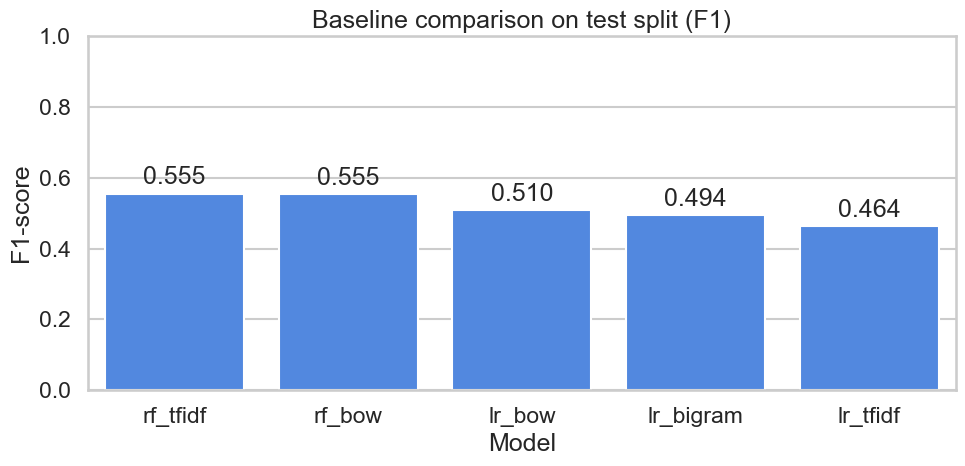

Saved: c:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\reports\figures\baseline_f1_comparison.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df[results_df['split'] == 'test'].copy()
plot_df = plot_df.sort_values('f1', ascending=False)
sns.barplot(data=plot_df, x='model', y='f1', ax=ax, color='#3B82F6')
ax.set_title('Baseline comparison on test split (F1)')
ax.set_xlabel('Model')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
fig.tight_layout()

baseline_fig_path = fig_dir / 'baseline_f1_comparison.png'
fig.savefig(baseline_fig_path, dpi=150)
plt.show()
plt.close(fig)

print('Saved:', baseline_fig_path)